# Conditionals: Session 2: while loops, break/continue, and pandas categoricals

**Objectives:** By the end of this session you will be able to:
- Write a `while` loop and explain when to use it instead of a `for` loop
- Use `break` to exit a loop early and `continue` to skip an iteration
- Work with categorical data in pandas using `.unique()` and `.value_counts()`

> **Reminder:** Booleans, comparison operators, and `if/elif/else` were covered in Session 1. Refer to that notebook if you need a refresher.

## while loops

A `for` loop runs once for each item in a sequence.  
A `while` loop runs **as long as a condition stays True**; you use it when you don't know in advance how many iterations you need.

```python
while condition:
    # body; runs as long as condition is True
```

> ⚠️ **Infinite loop danger:** If the condition never becomes False, the loop runs forever. Always make sure something inside the loop moves toward making the condition False. (You will see one in action in the `break` section.)

### ✏️ Flowchart exercise (draw on paper)

Draw a flowchart for this scenario:  
> A block wall goes up one 8-inch course at a time. Starting from 0, keep adding courses until the wall is 96 inches (8 ft) tall. Count the courses and print each step.

<details>
<summary><b>Show flowchart</b> (draw yours first)</summary>

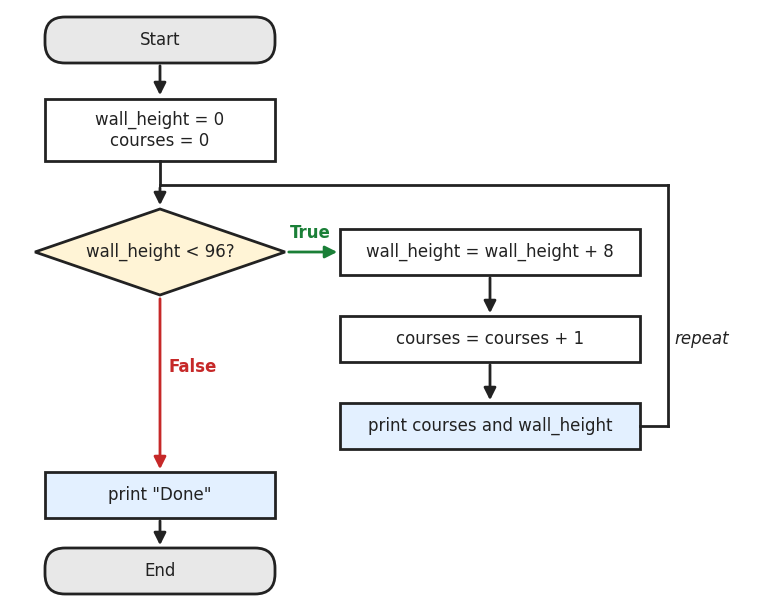

</details>

In [ ]:
wall_height = 0    # inches
courses = 0

while wall_height < 96:
    wall_height = wall_height + 8   # this is what moves us toward the exit condition
    courses = courses + 1
    print("Course", courses, "- wall is", wall_height, "in tall")

print("Done:", courses, "courses")

### Watch the wall go up

Run the setup cell, then run the same loop again. This time each pass through the loop draws the wall. The newest course is orange, and the line under the title shows the `while` check Python makes before the next pass.

`draw_wall()` and `wait()` are **visual only**: they are just for the picture, and you do not need to know them (they won't be on homework or exams). The rest of the loop is exactly the code above.

**Try it:** change `96` in the `while` line to `48`. How many courses now?

In [ ]:
# @title ▶ Run this first (sets up the wall drawing and the lights)
from IPython.display import display, HTML, clear_output
import time


def light(color, *message):
    """Show a colored indicator light with a message next to it."""
    text = ' '.join(str(m) for m in message)
    html = ('<div style="display:flex;align-items:center;gap:18px;'
            'font-family:sans-serif;font-size:22px;padding:8px 0">'
            '<div style="width:64px;height:64px;border-radius:50%;'
            'background:' + color + ';box-shadow:0 0 28px ' + color + ';'
            'border:3px solid #333"></div>'
            '<b>' + text + '</b></div>')
    display(HTML(html))


def wait(seconds=0.6):
    time.sleep(seconds)


def draw_wall(courses, wall_height, target=96):
    """Draw a cartoon block wall that is `courses` courses tall."""
    px = 4                      # pixels per inch
    block_w = 16 * px           # a CMU block is 16 in long
    block_h = 8 * px            # and 8 in tall
    blocks_across = 5
    left = 70                   # room for the ruler
    ground = 70 + target * px + 10
    width = left + blocks_across * block_w + 150
    height = ground + 40

    parts = []
    # sky and ground
    parts.append('<rect x="0" y="0" width="' + str(width) + '" height="' + str(ground) + '" fill="#eaf4ff"/>')
    parts.append('<rect x="0" y="' + str(ground) + '" width="' + str(width) + '" height="40" fill="#8bc34a"/>')

    # ruler
    for inch in range(0, target + 1, 16):
        y = ground - inch * px
        parts.append('<line x1="' + str(left - 14) + '" y1="' + str(y) + '" x2="' + str(left - 4) + '" y2="' + str(y) + '" stroke="#555" stroke-width="2"/>')
        parts.append('<text x="' + str(left - 18) + '" y="' + str(y + 5) + '" font-size="13" text-anchor="end" fill="#333">' + str(inch) + '"</text>')
    parts.append('<line x1="' + str(left - 4) + '" y1="' + str(ground) + '" x2="' + str(left - 4) + '" y2="' + str(ground - target * px) + '" stroke="#555" stroke-width="2"/>')

    # blocks, running bond (every other course shifted half a block)
    rows = min(int(wall_height // 8), 13)   # draw what wall_height says, not the course count
    for c in range(rows):
        y = ground - (c + 1) * block_h
        newest = (c == rows - 1)
        fill = '#ffb74d' if newest else '#bdbdbd'
        offset = 0 if c % 2 == 0 else block_w / 2
        x = left - offset
        while x < left + blocks_across * block_w:
            x0 = max(x, left)
            x1 = min(x + block_w, left + blocks_across * block_w)
            parts.append('<rect x="' + str(x0) + '" y="' + str(y) + '" width="' + str(x1 - x0) + '" height="' + str(block_h) + '" fill="' + fill + '" stroke="#757575" stroke-width="2"/>')
            x = x + block_w

    # target line
    ty = ground - target * px
    parts.append('<line x1="' + str(left - 4) + '" y1="' + str(ty) + '" x2="' + str(left + blocks_across * block_w + 20) + '" y2="' + str(ty) + '" stroke="#c62828" stroke-width="3" stroke-dasharray="10,6"/>')
    parts.append('<text x="' + str(left + blocks_across * block_w + 24) + '" y="' + str(ty + 5) + '" font-size="14" font-weight="bold" fill="#c62828">target 96"</text>')

    # the mason, standing on top of the newest course
    top = ground - rows * block_h
    mx = left + 2 * block_w
    parts.append('<text x="' + str(mx) + '" y="' + str(top - 4) + '" font-size="38">\U0001F477</text>')

    status = 'Course ' + str(courses) + ': wall is ' + str(wall_height) + ' in tall'
    if wall_height < target:
        check = 'wall_height &lt; 96? ' + str(wall_height) + ' &lt; 96 is <span style="color:#1a7f37">True</span>, so add another course'
    else:
        check = 'wall_height &lt; 96? ' + str(wall_height) + ' &lt; 96 is <span style="color:#c62828">False</span>, so the loop stops. Done!'
    svg = ('<svg xmlns="http://www.w3.org/2000/svg" width="' + str(width) + '" height="' + str(height) + '">'
           + ''.join(parts) + '</svg>')
    html = ('<div style="font-family:sans-serif"><div style="font-size:20px;font-weight:bold;margin:4px 0 8px">'
            + status + '</div><div style="font-family:monospace;font-size:16px;margin-bottom:8px">'
            + check + '</div>' + svg + '</div>')
    clear_output(wait=True)
    display(HTML(html))

def draw_beam(beam_height, moment_capacity, applied_moment, beam_width=2):
    """Draw the beam cross-section next to a capacity bar vs the applied moment."""
    ft = 40                                  # pixels per foot
    base = 300                               # y of the bottom of both drawings
    width = 560
    height = base + 40

    parts = []
    parts.append('<rect x="0" y="0" width="' + str(width) + '" height="' + str(height) + '" fill="#fafafa"/>')

    # beam cross-section (left)
    bw = beam_width * ft
    bh = beam_height * ft
    bx = 90 - bw / 2
    parts.append('<rect x="' + str(bx) + '" y="' + str(base - bh) + '" width="' + str(bw) + '" height="' + str(bh) + '" fill="#d7a86e" stroke="#6d4c2f" stroke-width="3"/>')
    parts.append('<text x="90" y="' + str(base + 22) + '" font-size="14" text-anchor="middle" fill="#333">beam cross-section</text>')
    parts.append('<text x="' + str(bx + bw + 8) + '" y="' + str(base - bh / 2 + 5) + '" font-size="14" fill="#333">' + str(beam_height) + ' ft</text>')

    # capacity bar (right)
    top_value = applied_moment * 1.4
    scale = (base - 30) / top_value
    cx = 330
    cap_h = min(moment_capacity, top_value) * scale
    safe = moment_capacity > applied_moment
    color = '#43a047' if safe else '#fb8c00'
    parts.append('<rect x="' + str(cx) + '" y="' + str(base - cap_h) + '" width="70" height="' + str(cap_h) + '" fill="' + color + '" stroke="#333" stroke-width="2"/>')
    parts.append('<text x="' + str(cx + 35) + '" y="' + str(base + 22) + '" font-size="14" text-anchor="middle" fill="#333">moment_capacity</text>')
    ay = base - applied_moment * scale
    parts.append('<line x1="' + str(cx - 20) + '" y1="' + str(ay) + '" x2="' + str(cx + 90) + '" y2="' + str(ay) + '" stroke="#c62828" stroke-width="3" stroke-dasharray="10,6"/>')
    parts.append('<text x="' + str(cx + 96) + '" y="' + str(ay + 5) + '" font-size="14" font-weight="bold" fill="#c62828">applied ' + str(applied_moment) + '</text>')
    parts.append('<line x1="0" y1="' + str(base) + '" x2="' + str(width) + '" y2="' + str(base) + '" stroke="#333" stroke-width="2"/>')

    title = 'beam_height = ' + str(beam_height) + ' ft, moment_capacity = ' + str(moment_capacity)
    if safe:
        check = ('moment_capacity &lt;= ' + str(applied_moment) + '? <span style="color:#c62828">False</span>, '
                 'so the loop stops. This beam is strong enough!')
    else:
        check = ('moment_capacity &lt;= ' + str(applied_moment) + '? <span style="color:#1a7f37">True</span>, '
                 'so make the beam taller')
    svg = ('<svg xmlns="http://www.w3.org/2000/svg" width="' + str(width) + '" height="' + str(height) + '">'
           + ''.join(parts) + '</svg>')
    html = ('<div style="font-family:sans-serif"><div style="font-size:18px;font-weight:bold;margin:4px 0 6px">'
            + title + '</div><div style="font-family:monospace;font-size:15px;margin-bottom:8px">'
            + check + '</div>' + svg + '</div>')
    clear_output(wait=True)
    display(HTML(html))

def draw_counts(project_type, rental, homeownership, special_needs):
    """Draw three tally bars; the bar for the project just counted is highlighted."""
    labels = ['Rental', 'Homeownership', 'Special Needs']
    values = [rental, homeownership, special_needs]
    names = ['rental', 'homeownership', 'special_needs']
    unit = 10                          # pixels per project
    base = 300
    width = 560
    height = base + 50
    parts = ['<rect x="0" y="0" width="' + str(width) + '" height="' + str(height) + '" fill="#fafafa"/>']
    for i in range(3):
        x = 50 + i * 170
        h = values[i] * unit
        current = (labels[i] == project_type)
        fill = '#ffb74d' if current else '#90caf9'
        parts.append('<rect x="' + str(x) + '" y="' + str(base - h) + '" width="110" height="' + str(h) + '" fill="' + fill + '" stroke="#333" stroke-width="2"/>')
        parts.append('<text x="' + str(x + 55) + '" y="' + str(base - h - 8) + '" font-size="20" font-weight="bold" text-anchor="middle" fill="#333">' + str(values[i]) + '</text>')
        parts.append('<text x="' + str(x + 55) + '" y="' + str(base + 22) + '" font-size="14" text-anchor="middle" fill="#333">' + labels[i] + '</text>')
        parts.append('<text x="' + str(x + 55) + '" y="' + str(base + 40) + '" font-size="12" font-family="monospace" text-anchor="middle" fill="#666">' + names[i] + '</text>')
    parts.append('<line x1="20" y1="' + str(base) + '" x2="' + str(width - 20) + '" y2="' + str(base) + '" stroke="#333" stroke-width="2"/>')
    total = rental + homeownership + special_needs
    title = 'Project ' + str(total) + ': ' + project_type + ', so add 1 to that counter'
    svg = ('<svg xmlns="http://www.w3.org/2000/svg" width="' + str(width) + '" height="' + str(height) + '">'
           + ''.join(parts) + '</svg>')
    clear_output(wait=True)
    display(HTML('<div style="font-family:sans-serif"><div style="font-size:18px;font-weight:bold;margin:4px 0 8px">'
                 + title + '</div>' + svg + '</div>'))


print('Ready!')


In [ ]:
wall_height = 0    # inches
courses = 0

while wall_height < 96:
    wall_height = wall_height + 8
    courses = courses + 1
    draw_wall(courses, wall_height)   # visual only: you do not need to know this
    wait()   # visual only: pauses so you can watch

print("Done:", courses, "courses")

### Watch a while loop run

The ventilation fan keeps running **while** the CO2 level is above 1000 ppm. Each pass through the loop the fan removes 100 ppm. Run the loop: a new light comes on for each pass.

`light()` works just like `print()`: give it a color, then the message. `light()` and `wait()` are **visual only**: you do not need to know them, and in your own code you would use `print()`.

**Try it:** change the starting `co2` to 900. What happens, and why?

In [ ]:
co2 = 1500   # ppm

while co2 > 1000:
    light('red', 'Fan running... CO2 =', co2, 'ppm')   # visual only: in your own code, use print()
    co2 = co2 - 100
    wait()   # visual only: pauses so you can watch

light('limegreen', 'Air OK: CO2 =', co2, 'ppm')   # visual only: in your own code, use print()

## HVAC Example: Adjusting Room Temperature

A building automation system keeps adjusting an HVAC unit until the room hits the setpoint temperature.

**Your Turn #1:** write the `while` loop that keeps adjusting the room temperature until it reaches the setpoint. Print the temperature at each step, like the example above.

In [ ]:
# Your Turn #1: use a while loop to raise room_temperature by adjustment_rate
# until it reaches setpoint. Print the temperature at each step, then the final temperature
room_temperature  = 65    # °F, current reading
setpoint          = 72    # °F, desired setpoint
adjustment_rate   =  0.5  # °F per step


## Load the radon data

The `break` and `continue` examples below use the same indoor air quality (radon) readings from Session 1. Run the next two cells to load them into `iaq_df`.

In [ ]:
import pandas as pd
import requests

url = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/EZgpsrR5Q61CrlL0XqOmW80BnRAIYy0xJmS4X1B14sVMjg?e=E8xR91'
r = requests.get(url + '&download=1')
with open('radon.csv', 'w') as f:
    f.write(r.text)
print(r.status_code)   # 200 means the download worked

In [ ]:
iaq_df = pd.read_csv('radon.csv')
print(iaq_df.head())

## break: exit a loop early

`break` immediately stops the loop, even if the condition is still True (or there are items left).  
Use it when you've found what you were looking for and don't need to keep going.

In [ ]:
# A short list first, so you can see every step
readings = [1.2, 2.5, 4.6, 3.0, 5.1]   # pCi/L

for reading in readings:
    print("Checking", reading, "pCi/L")
    if reading > 4.0:
        print(reading, "is above 4.0, stopping")
        break

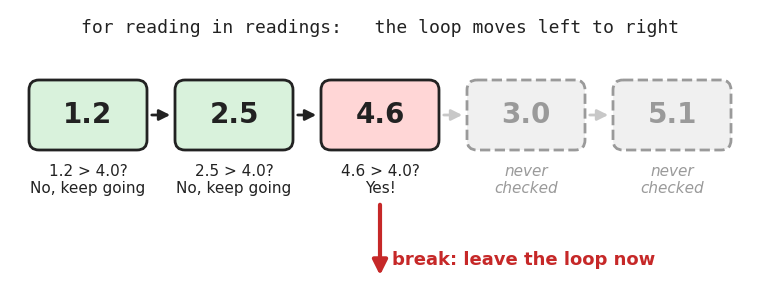

Notice that 3.0 and 5.1 were never checked. Now do the same thing with the full radon data:

In [ ]:
# lets code together
# Stop as soon as we find the first radon reading above the action level
action_level = 4.0   # pCi/L


### Real-world break: pick the first beam that works

Engineers size beams this way: start with the smallest (cheapest) board and **stop at the first one that is strong enough**. Once a board works, checking bigger ones is wasted effort, so we `break`.

A floor joist has to carry a bending moment. For a rectangular board, `section_modulus = width * depth * depth / 6`, and the bending stress is `moment / section_modulus`. The board passes if the stress is at or below the allowable stress for the wood.

Run the cell: one light comes on for each board we check. **How many lights do you see? Which board never got checked?**

In [ ]:
# Floor joist: try the smallest board first, stop at the first one strong enough
moment = 18000      # lb-in, bending moment from the floor load
allowable = 1000    # psi, allowable bending stress for the wood
width = 1.5         # in, actual width of a 2x board

depths = [5.5, 7.25, 9.25, 11.25]   # in, actual depths of a 2x6, 2x8, 2x10, 2x12

for depth in depths:
    section_modulus = width * depth * depth / 6   # in^3
    stress = moment / section_modulus             # psi
    if stress <= allowable:
        light('limegreen', depth, 'in deep: PASS, stress =', stress, 'psi. Use this one!')   # visual only: in your own code, use print()
        break
    else:
        light('red', depth, 'in deep: FAIL, stress =', stress, 'psi')   # visual only: in your own code, use print()

**Your Turn #2:** A concrete batch is accepted only if **every** test cylinder reaches the required strength of 4000 psi. Test the cylinders in order. As soon as one is too weak, the whole batch is rejected, so use `break` to stop testing. Print each cylinder's strength. (Optional: use `light()` instead of `print()` to see it light up.)

Strength is the same formula as Lesson 1: `strength = load / area`.

In [ ]:
# Your Turn #2: test the cylinders in order
# Stop with break at the first cylinder whose strength is below required_strength
area = 28.27                # sq in (6-inch diameter cylinder)
required_strength = 4000    # psi
crush_loads = [125000, 118000, 109000, 121000, 130000]   # lbs at which each cylinder crushed


### `break` as a safety cap: the wall that never finishes

Here is the wall loop with a bug: we forgot the line `wall_height = wall_height + 8`. Since `wall_height` never changes, `wall_height < 96` is **always True**. That is an **infinite loop**: the worker keeps going, but the wall never gets taller.

Real control code (like a building's HVAC controller) protects itself with a **safety cap**: if the loop has run too many times, `break` out. Run it and watch the course counter climb while the wall stays at 0.

**Try it:** fix the bug so the wall finishes on its own.

In [ ]:
wall_height = 0    # inches
courses = 0

while wall_height < 96:
    # BUG: we forgot  wall_height = wall_height + 8
    courses = courses + 1
    draw_wall(courses, wall_height)   # visual only: you do not need to know this
    wait(0.3)   # visual only: pauses so you can watch

    if courses == 15:   # safety cap: never more than 15 tries
        print("Safety cap! After", courses, "tries the wall is still", wall_height, "in tall.")
        print("Without the cap, this loop would never end.")
        break

## continue: skip one iteration

`continue` skips the rest of the current iteration and jumps to the next one.  
Use it when you want to ignore certain rows without stopping the whole loop.

In [ ]:
# A short list first, so you can see every step
readings = [1.2, 2.5, 4.6, 3.0, 5.1]   # pCi/L

for reading in readings:
    if reading <= 4:
        print("Skipping", reading, "pCi/L")
        continue
    print(reading, "pCi/L, POOR, action required")

**Your Turn #3:** loop over the radon readings and print only the POOR ones (above 4 pCi/L). Use `continue` to skip everything else.

In [ ]:
# Your Turn #3: print only the POOR readings (above 4 pCi/L)
# Use continue to skip the Good and Fair readings


### `break` vs `continue`, side by side

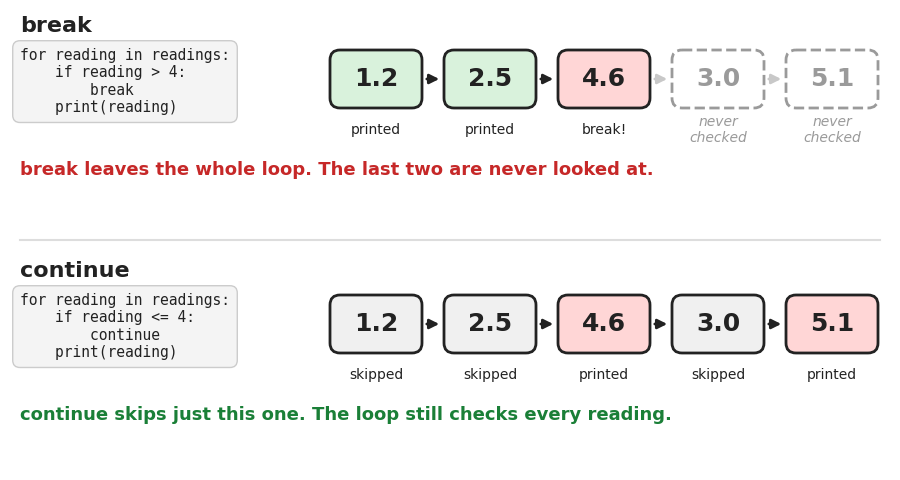 4: break), 1.2 and 2.5 are printed, the loop stops at 4.6, and 3.0 and 5.1 are never checked. With continue (if reading <= 4: continue), 1.2, 2.5 and 3.0 are skipped, 4.6 and 5.1 are printed, and every reading is checked." width="760">

- `break`: **stop the whole loop** right now.
- `continue`: **skip just this one** and go on to the next.

## Categorical Data in pandas

A **categorical variable** has a fixed set of possible values, like building type, project status, or room classification.  
Pandas has tools specifically for working with these.

### Meet the dataset: affordable housing projects

This dataset lists **401 affordable housing projects** built in Philadelphia between 1995 and 2019 with public support. (HUD is the U.S. Department of Housing and Urban Development, which funds affordable housing.) Each row is one project.

| Column | What it means | Type | Example (Cantrell Place) |
|---|---|---|---|
| `OBJECTID` | Row ID number | number | 5 |
| `FISCAL_YEAR_COMPLETE` | Year the project was finished | number | 2019 |
| `PROJECT_NAME` | Name of the project | text | Cantrell Place |
| `DEVELOPER_NAME` | Organization that built it | text | Presby's Inspired Life |
| `ADDRESS` | Street address | text | 447 CANTRELL ST |
| **`PROJECT_TYPE`** | **Rental, Homeownership, or Special Needs** (housing with support services, e.g. for seniors) | **text (categorical)** | Rental |
| **`TOTAL_UNITS`** | **Number of homes or apartments in the project** | **number** | 61 |
| `ACCESSIBLE_UNITS` | Units built for wheelchair users | number | 8 |
| `SENSORY_UNITS` | Units adapted for residents with hearing or vision loss | number | 4 |
| `VISITABLE_UNITS` | Units a wheelchair user can visit (step-free entry, wide doors) | number | 61 |

Today we only use the two **bold** columns: `PROJECT_TYPE` (categorical) and `TOTAL_UNITS` (numeric). The three accessibility columns are blank for most projects, which will show up as `NaN`.

Run the next two cells to load it.

In [ ]:
import pandas as pd
import requests

url = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/ESEBzfo41jtIjrovJyKO4igBCFPET9ycHLX9LrQWwkz3qQ?e=FS9QIr'
r = requests.get(url + '&download=1')
with open('data.csv', 'w') as f:
    f.write(r.text)
print(r.status_code)   # 200 means the download worked

In [ ]:
data = pd.read_csv('data.csv')
print(data.head())

In [ ]:
# What data types do we have?
data.dtypes

Which columns look categorical (text labels with a fixed set of options) vs numeric?

In [ ]:
# lets code together
# See what unique project types exist


### What `value_counts()` does behind the scenes

Before we use `value_counts()`, let's count the project types ourselves for the first 40 projects. We keep one counter per type, and the `if / elif / else` decides which counter gets `+ 1`.

In [ ]:
first_40 = data.head(40)

rental = 0
homeownership = 0
special_needs = 0

for project_type in first_40['PROJECT_TYPE']:
    if project_type == 'Rental':
        rental = rental + 1
    elif project_type == 'Homeownership':
        homeownership = homeownership + 1
    else:
        special_needs = special_needs + 1

print("Rental:", rental, "Homeownership:", homeownership, "Special Needs:", special_needs)

**Now watch it happen.** This is the same loop with two extra lines at the bottom that draw the counters as bars, one project at a time. The lines marked *visual only* are just for the picture; you do not need to know them.

In [ ]:
first_40 = data.head(40)

rental = 0
homeownership = 0
special_needs = 0

for project_type in first_40['PROJECT_TYPE']:
    if project_type == 'Rental':
        rental = rental + 1
    elif project_type == 'Homeownership':
        homeownership = homeownership + 1
    else:
        special_needs = special_needs + 1
    draw_counts(project_type, rental, homeownership, special_needs)   # visual only: you do not need to know this
    wait(0.2)   # visual only: pauses so you can watch

print("Rental:", rental, "Homeownership:", homeownership, "Special Needs:", special_needs)

`value_counts()` does that whole loop for you in one line. Check that the numbers match:

In [ ]:
first_40['PROJECT_TYPE'].value_counts()

In [ ]:
# Your Turn #4: count how many projects of each type


Now visualize it as a bar chart:

In [ ]:
import matplotlib.pyplot as plt

counts = data['PROJECT_TYPE'].value_counts()
print(counts)

In [ ]:
fig_types, ax_types = plt.subplots(figsize=(8, 5))
ax_types.bar(counts.index, counts.values)
ax_types.set_xlabel('Project Type')
ax_types.set_ylabel('Number of Projects')
ax_types.set_title('HUD Projects by Type')
ax_types.tick_params(axis='x', rotation=15)
fig_types

## Connecting categoricals to conditionals

Start with the first 25 projects so you can check each one against the table:

In [ ]:
first_projects = data.head(25)
print(first_projects[['PROJECT_NAME', 'TOTAL_UNITS']])

In [ ]:
# lets code together
# Flag projects with a large number of units using a conditional
threshold = 50


## In-Class Assignment

Using the HUD dataset:
1. Count how many projects have `TOTAL_UNITS` > 100 using a loop and a counter variable
2. Print which `PROJECT_TYPE` appears most often (you can use `.value_counts()`)

**Submission:** Take a screengrab of your code and output and submit to Canvas.

In [ ]:
# your code here


## Extra Practice (optional)

These are **not graded** and you don't submit them. They are extra reps if you finish early or want more practice after class. Try each one yourself before you open the answer.

### Extra Practice #1: how long to cool down?

After the HVAC turns on, a server room at **80 °F** cools by **1.5 °F every hour**. Use a `while` loop to find how many hours it takes to get down to **70 °F or lower**. Print the number of hours and the final temperature.

**Hint:** keep a counter for the hours and add 1 to it each time through the loop.

In [ ]:
# Extra Practice #1


<details>
<summary><b>Show answer</b></summary>

```python
temperature = 80   # °F
hours = 0

while temperature > 70:
    temperature = temperature - 1.5
    hours = hours + 1
    print("Hours:", hours, "Temperature:", temperature, "°F")

print("It took", hours, "hours to reach", temperature, "°F")

# It took 7 hours to reach 69.5 °F
```

</details>

### Extra Practice #2: find the first big project

Loop over the `TOTAL_UNITS` column and find the **first** project with more than **200** units. Print its number of units, then use `break` to stop looking.

In [ ]:
# Extra Practice #2


<details>
<summary><b>Show answer</b></summary>

```python
for units in data['TOTAL_UNITS']:
    if units > 200:
        print("First project over 200 units:", units, "units")
        break

# First project over 200 units: 224.0 units
```

</details>

### Extra Practice #3: skip one project type

Loop over the `PROJECT_TYPE` column and count how many projects are **not** Homeownership. Use `continue` to skip the Homeownership projects.

**Check yourself:** compare your count with the `value_counts()` output from earlier.

In [ ]:
# Extra Practice #3


<details>
<summary><b>Show answer</b></summary>

```python
count = 0

for project_type in data['PROJECT_TYPE']:
    if project_type == 'Homeownership':
        continue   # skip this one and go to the next project
    count = count + 1

print("Projects that are not Homeownership:", count)

# Projects that are not Homeownership: 292  (Rental 176 + Special Needs 116)
```

</details>

### Extra Practice #4: grow the beam until it is strong enough

A beam has to carry an **applied moment of 50 lb-ft**. Its moment capacity is

`moment_capacity = 0.9 * beam_width * beam_height * beam_height`

Start with `beam_width = 2` ft and `beam_height = 1.0` ft. Use a `while` loop that keeps going **as long as `moment_capacity <= applied_moment`**. Each time through the loop, make the beam **0.5 ft taller** and recalculate `moment_capacity`. After the loop, print the final beam height and its capacity.

**Watch it grow:** inside your loop, add `draw_beam(beam_height, moment_capacity, applied_moment)` and `wait()` (the setup cell near the top of the notebook has to be run first).

In [ ]:
# Extra Practice #4


<details>
<summary><b>Show answer</b></summary>

```python
applied_moment = 50   # lb-ft
beam_width = 2        # ft
beam_height = 1.0     # ft
moment_capacity = 0.9 * beam_width * beam_height * beam_height

while moment_capacity <= applied_moment:
    beam_height = beam_height + 0.5
    moment_capacity = 0.9 * beam_width * beam_height * beam_height
    draw_beam(beam_height, moment_capacity, applied_moment)   # visual only: you do not need to know this
    wait()   # visual only: pauses so you can watch

print("Final beam height:", beam_height, "ft")
print("Moment capacity:", moment_capacity, "lb-ft")

# Final beam height: 5.5 ft
# Moment capacity: 54.45 lb-ft
```

</details>

### Extra Practice #5: step through a list with a counter

Many real problems give you a new number every day, like a weather forecast or a production log. Then you can't solve for the answer with one formula: you have to add it up one day at a time. Use a counter (`day`) to pick out each day's value from the list. Remember that Python counts from 0, so `daily_solar[0]` is the first day. Exam 2 uses this kind of loop.

A building's rooftop solar panels charge a **50 kWh battery**. The forecast for how much energy the panels make each day is below. Start with `stored = 0` and `day = 0`. Use a `while` loop that keeps going **as long as `stored < battery_capacity`**. Each time through the loop, add that day's energy (`stored = stored + daily_solar[day]`) and then move to the next day (`day = day + 1`). After the loop, print the day the battery is full and how much energy is stored.

```python
daily_solar = [12.5, 8.0, 0, 15.5, 10.0, 3.5, 14.0, 16.5, 11.0, 9.5]   # kWh produced each day
battery_capacity = 50   # kWh
```

**Think about it:** what would happen if you forgot `day = day + 1`?

In [ ]:
# Extra Practice #5


<details>
<summary><b>Show answer</b></summary>

```python
daily_solar = [12.5, 8.0, 0, 15.5, 10.0, 3.5, 14.0, 16.5, 11.0, 9.5]   # kWh produced each day
battery_capacity = 50   # kWh
stored = 0
day = 0

while stored < battery_capacity:
    stored = stored + daily_solar[day]
    day = day + 1

print("The battery is full after day", day)
print("Stored energy:", stored, "kWh")

# The battery is full after day 7
# Stored energy: 63.5 kWh
```

If you forgot `day = day + 1`, `day` would stay at 0, so the loop would add the first day's 12.5 kWh every time. It would still stop, but it would say the battery is full after day **0**, which is wrong. The day 3 value of 0 is a cloudy day: the battery doesn't charge at all, which is why you can't just divide 50 by an average.

</details>